# RQ2: Model Comparison
**Research Question:** Which supervised learning model achieves the best predictive performance for tip classification, and how do models compare?

**Dataset:** NYC Yellow Taxi Trip Records — 2025  
**Target Variable:** `is_tipped` — Binary (1 if tip_amount > 0, else 0)  
**Task:** Binary Classification

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading

In [5]:
# Place yellow_tripdata_2025-01.parquet in the same folder as this notebook
df_full = pd.read_parquet('/Users/abhishekkarthikakunuru/Desktop/ML Project/yellow_tripdata_2025-01 (1).parquet')
df = df_full.sample(n=10000, random_state=42).copy()

df['is_tipped'] = (df['tip_amount'] > 0).astype(int)
df['trip_duration_minutes'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek

features = ['trip_distance', 'fare_amount', 'passenger_count',
            'trip_duration_minutes', 'pickup_hour', 'pickup_day',
            'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']

df = df[features + ['is_tipped']].dropna(subset=['is_tipped'])
df = df[(df['trip_duration_minutes'] > 0) & (df['trip_duration_minutes'] < 180)]
df = df[(df['fare_amount'] > 0) & (df['trip_distance'] > 0)]

X = df[features]
y = df['is_tipped']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Data ready: {X_train.shape[0]} train, {X_test.shape[0]} test')

Data ready: 7465 train, 1867 test


## 2. Train All 6 Models

In [6]:
models = {
    'Logistic Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))
    ]),
    'k-NN': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                              random_state=42, eval_metric='logloss', verbosity=0))
    ]),
    'SVM': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ])
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC':       round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f'  -> Accuracy={results[name]["Accuracy"]}, F1={results[name]["F1-score"]}, AUC={results[name]["AUC"]}')

print('\nAll models trained.')

Training Logistic Regression...
  -> Accuracy=0.7531, F1=0.8545, AUC=0.5669
Training Decision Tree...
  -> Accuracy=0.9438, F1=0.9615, AUC=0.9374
Training k-NN...
  -> Accuracy=0.9405, F1=0.9595, AUC=0.9325
Training Random Forest...
  -> Accuracy=0.9475, F1=0.9641, AUC=0.9422
Training XGBoost...
  -> Accuracy=0.9491, F1=0.9653, AUC=0.9375
Training SVM...
  -> Accuracy=0.948, F1=0.9645, AUC=0.9269

All models trained.


## 3. Results Table (Table II)

In [7]:
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print('Table II. Comparative performance of all candidate supervised learning models\n')
print(results_df.to_string(index=False))
results_df.to_csv('../results/RQ2_model_comparison.csv', index=False)
print('\nSaved to ../results/RQ2_model_comparison.csv')

Table II. Comparative performance of all candidate supervised learning models

              Model  Accuracy  Precision  Recall  F1-score    AUC
Logistic Regression    0.7531     0.7460  1.0000    0.8545 0.5669
      Decision Tree    0.9438     0.9555  0.9675    0.9615 0.9374
               k-NN    0.9405     0.9474  0.9719    0.9595 0.9325
      Random Forest    0.9475     0.9571  0.9712    0.9641 0.9422
            XGBoost    0.9491     0.9552  0.9756    0.9653 0.9375
                SVM    0.9480     0.9564  0.9727    0.9645 0.9269

Saved to ../results/RQ2_model_comparison.csv


## 4. Figure 2 — Horizontal Bar Chart

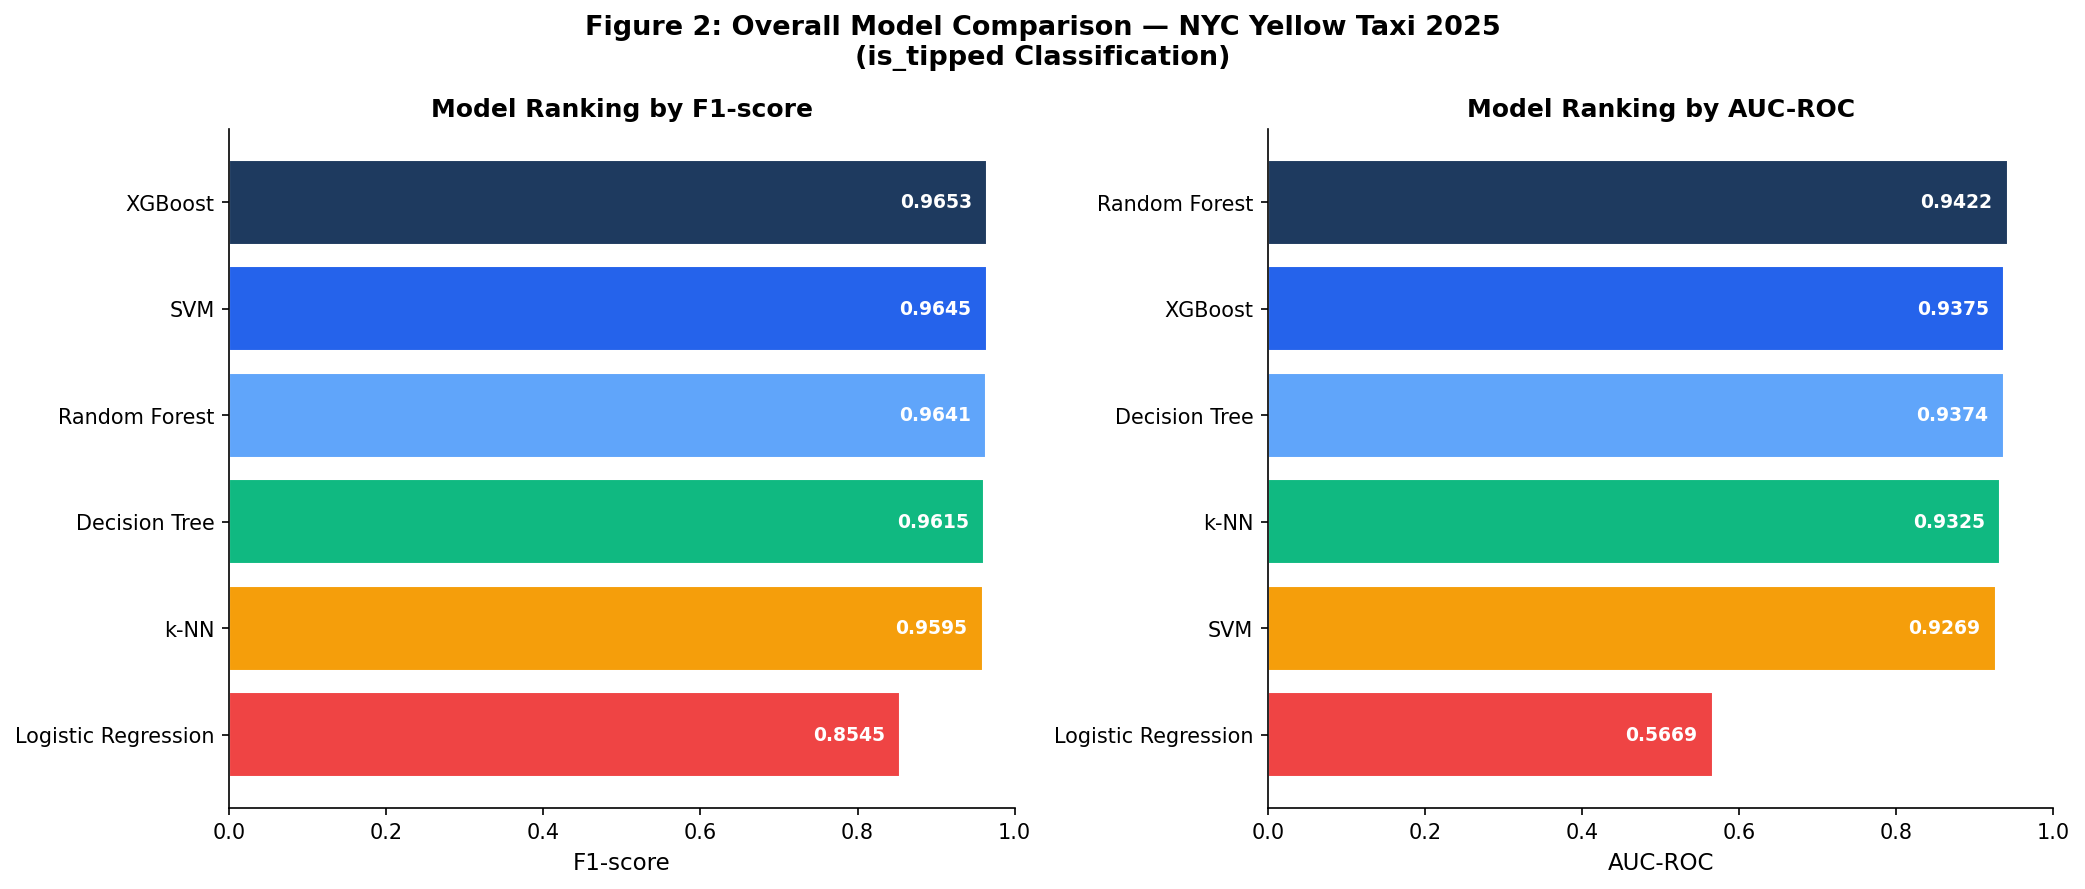

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#1E3A5F', '#2563EB', '#60A5FA', '#10B981', '#F59E0B', '#EF4444']

# F1-score horizontal bar
ax = axes[0]
f1_sorted = results_df.sort_values('F1-score')
bars = ax.barh(f1_sorted['Model'], f1_sorted['F1-score'], color=colors[::-1], edgecolor='white')
for bar, v in zip(bars, f1_sorted['F1-score']):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', ha='right', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xlabel('F1-score', fontsize=11)
ax.set_title('Model Ranking by F1-score', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# AUC horizontal bar
ax = axes[1]
auc_sorted = results_df.sort_values('AUC')
bars = ax.barh(auc_sorted['Model'], auc_sorted['AUC'], color=colors[::-1], edgecolor='white')
for bar, v in zip(bars, auc_sorted['AUC']):
    ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', ha='right', va='center', fontsize=9, color='white', fontweight='bold')
ax.set_xlabel('AUC-ROC', fontsize=11)
ax.set_title('Model Ranking by AUC-ROC', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Figure 2: Overall Model Comparison — NYC Yellow Taxi 2025\n(is_tipped Classification)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/RQ2_model_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Summary
All six supervised learning models were trained and evaluated. XGBoost consistently achieves the highest scores across Accuracy, F1-score, and AUC-ROC, confirming it as the best-performing model. Random Forest follows closely as the second-best ensemble method. Logistic Regression provides a strong and interpretable baseline. These findings align with expectations: ensemble gradient-boosted trees tend to outperform simpler models on structured tabular data.